# sunpy tutorial

In [1]:
import pathlib

import sunpy
sunpy.log.setLevel('ERROR')

DATA_DIR = pathlib.Path('./')

In this notebook, we will learn about the basic parts of the `sunpy` package as well as how `sunpy` makes use of several core components of the `astropy` package. By the end of this tutorial you will know how to:

- Create and manipulate unitful quantities with `astropy.units`
- Create and do basic arithmetic with `astropy.time.Time` objects 
- Search for data from many different data providers with `sunpy`
- Load, manipulate, and visualize 2D images data with `sunpy.map.Map`
- Do basic coordinate tranformations with the `astropy.coordinates` framework, include solar coordinate frames
- Create and visualize time series data with `sunpy.timeseries.TimeSeries`

## Part 0 - `astropy.units`

Let us start with values and scientific units. Often when we reperesent unitful quantities in code, we assume a particular unit system, maybe providing context in a comment.

In [2]:
speed = 100 # km/s
speed_kms = 100
speed_cms = speed_kms * 100

This doesn't scale and mistakes can be made. Google "Mars Climate Orbiter" for an example of when units go wrong.

`astropy` includes a powerful framework for units that allows users to attach units to scalars and arrays.
These quantities can be manipulated or combined while keeping track of the units.

For more information about the features presented below, please see the [astropy.units](http://docs.astropy.org/en/stable/units/index.html) documentation.

In [3]:
import astropy.units as u

The primary goal of the `astropy.units` package is to be able to store, convert, display units in code.

In [4]:
u.meter

Unit("m")

In [5]:
?u.m

Type:            IrreducibleUnit
String form:     m
File:            ~/micromamba/envs/sunpy-dev/lib/python3.13/site-packages/astropy/units/core.py
Docstring:       meter: base unit of length in SI
Class docstring:
Irreducible units are the units that all other units are defined
in terms of.

Examples are meters, seconds, kilograms, amperes, etc.  There is
only once instance of such a unit per type.

Notice that meter also has a shorthand called "m".

You can create 1 unit, a range of units, and convert the unit.

In [ ]:
100 * u.meter

<Quantity 100. m>

In [12]:
[1, 2, 4, 8] * u.km

<Quantity [1., 2., 4., 8.] km>

In [13]:
(100 * u.meter).to(u.AA)

<Quantity 1.e+12 Angstrom>

This system also ensures that arithmetic operations between quantities make sense.

In [14]:
10 * u.meter + 100 * u.cm

<Quantity 11. m>

In [16]:
# This will error, don't worry about the really large error message
1 * u.meter + 1 * u.gram

UnitConversionError: Can only apply 'add' function to quantities with compatible dimensions

In addition, there are fixed constants like G and c.

In [26]:
from astropy.constants import G, c

print(G, c, sep='\n\n')

  Name   = Gravitational constant
  Value  = 6.6743e-11
  Uncertainty  = 1.5e-15
  Unit  = m3 / (kg s2)
  Reference = CODATA 2018

  Name   = Speed of light in vacuum
  Value  = 299792458.0
  Uncertainty  = 0.0
  Unit  = m / s
  Reference = CODATA 2018


Quantities also support conversion to *equivalent* unit systems (but you have to tell it!).

In [27]:
(500*u.nm).to(u.Hz)

UnitConversionError: 'nm' (length) and 'Hz' (frequency) are not convertible

For this to work, we need to tell `astropy.units` the specific assumption we want to make about how these units are related.

In [ ]:
(500*u.nm).to(u.Hz, u.spectral())

<Quantity 5.99584916e+14 Hz>

This is useful for working out line-of-sight velocities

In [29]:
?u.doppler_optical

Signature: u.doppler_optical(rest)
Docstring:
Return the equivalency pairs for the optical convention for velocity.

The optical convention for the relation between velocity and frequency is:

:math:`V = c \frac{f_0 - f}{f  }  ;  f(V) = f_0 ( 1 + V/c )^{-1}`

Parameters
----------
rest : `~astropy.units.Quantity`
    Any quantity supported by the standard spectral equivalencies
    (wavelength, energy, frequency, wave number).

References
----------
`NRAO site defining the conventions <https://www.gb.nrao.edu/~fghigo/gbtdoc/doppler.html>`_

Examples
--------
>>> import astropy.units as u
>>> CO_restfreq = 115.27120*u.GHz  # rest frequency of 12 CO 1-0 in GHz
>>> optical_CO_equiv = u.doppler_optical(CO_restfreq)
>>> measured_freq = 115.2832*u.GHz
>>> optical_velocity = measured_freq.to(u.km/u.s, equivalencies=optical_CO_equiv)
>>> optical_velocity  # doctest: +FLOAT_CMP
<Quantity -31.20584348799674 km / s>
File:      ~/micromamba/envs/sunpy-dev/lib/python3.13/site-packages/astropy/units

Say we see a small shift for a line profile at 304 Angstrom which is 303.5 Angstrom

In [39]:
(303.9*u.AA).to(u.km/u.s, equivalencies=u.doppler_optical(304*u.AA))

<Quantity -98.61594013 km / s>

These unitful quantities can also be passed to `numpy` functions.

In [40]:
import numpy as np

In [41]:
np.sin(90 * u.degree)

<Quantity 1.>

In [42]:
np.sin(30 * u.rad)

<Quantity -0.98803162>

Lots of methods and functions in `sunpy` require values to have units attached to them.
The first case will be us downloading data.

## Part 1 - Data Search and Download with `Fido`

In [43]:
from sunpy.net import Fido, attrs as a

/Users/nabil/micromamba/envs/sunpy-dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Overview of the `Fido` Unified Downloader

* Fido is sunpy's interface for searching and downloading solar physics data.
* It offers a unified interface for searching and fetching data irrespective of the underlying client or web service from where the data is obtained.
* Offers a way to search and accesses multiple instruments and all available data providers in a single query.
* It supplies a single, easy, consistent and *extendable* way to get most forms of solar physics data the community need 

Fido currently offers access to data available through:

 * **Virtual Solar Observatory (VSO)**
 * **Joint Science Operations Center (JSOC)**
 * **Individual data providers** from web accessible sources (http, ftp, etc)
 * **Heliophysics Events Knowledgebase (HEK)**
 * **Heliophysics Feature Catalogue (HELIO)**
 * Other sources via a plugin system
 
As described here Fido provides access to many sources of data through different `clients`, these clients can be defined inside sunpy or in other packages.

Lets print the current list of available clients within sunpy.

In [46]:
Fido

Client,Description
CDAWEBClient,Provides access to query and download from the Coordinated Data Analysis Web (CDAWeb).
ADAPTClient,Provides access to the ADvanced Adaptive Prediction Technique (ADAPT) products of the National Solar Observatory (NSO).
EVEClient,Provides access to Level 0CS Extreme ultraviolet Variability Experiment (EVE) data.
GBMClient,Provides access to data from the Gamma-Ray Burst Monitor (GBM) instrument on board the Fermi satellite.
XRSClient,Provides access to several GOES XRS files archive.
SUVIClient,Provides access to data from the GOES Solar Ultraviolet Imager (SUVI).
GONGClient,Provides access to the Magnetogram products of NSO-GONG synoptic Maps.
LYRAClient,Provides access to the LYRA/Proba2 data archive.
NOAAIndicesClient,Provides access to the NOAA solar cycle indices.
NOAAPredictClient,Provides access to the NOAA SWPC predicted sunspot Number and 10.7 cm radio flux values.


### Searching for Data

sunpy uses specified *attributes* to search for data using Fido.
These search attributes can be combined together to construct data search queries, such as searching over a certain time period or for data from a specific instrument observing in a certain wavelength.

Different clients may have client-specific attributes, but the core attributes are:

* `a.Time`
* `a.Instrument`
* `a.Wavelength`

Let's use these different attributes to construct a query for our CME observation.

In [47]:
cme_start = "2022-03-28T11:00"
cme_end = "2022-03-28T14:00"

In [48]:
cme_time = a.Time(cme_start, cme_end)

What is this time object?

In [49]:
cme_time

<sunpy.net.attrs.Time(2022-03-28 11:00:00.000, 2022-03-28 14:00:00.000)>

In [50]:
cme_time.start

<Time object: scale='utc' format='isot' value=2022-03-28T11:00:00.000>

In [51]:
 type(cme_time.start)

astropy.time.core.Time

### Aside - `astropy.time.Time`

Python already has a built-in datetime package which handles standard dates, times, timezones and time deltas.

In [69]:
import datetime

datetime.datetime.now()

datetime.datetime(2025, 2, 13, 20, 28, 53, 944088)

So why do we need `astropy.time`?

Three main areas:

 - Astronomical formats (e.g., Julian Date (JD), Modified JD (MJD))
 - Precise timing (e.g., a nanosecond over a Hubble Time)
 - Leap seconds and special time epochs like UT seconds from 1979-01-01 00:00:00 UTC

The first two are not supported by the standard datetime library.

So let us import the time objects from astropy

In [90]:
from astropy.time import Time, TimeDelta

The MJD for a given date is the number of days to that date since Jan 1 4713 B.C. 00:00:00 (midnight).

In [91]:
time = Time(58086.182, format='mjd')

In [92]:
time

<Time object: scale='utc' format='mjd' value=58086.182>

You can represent these `Time` objects in other formats.

In [93]:
time.jd

np.float64(2458086.682)

In [94]:
time.isot

'2017-11-29T04:22:04.800'

We can also do arithmetic with `Time`

In [95]:
time - TimeDelta(1, format='jd') # Defaults to days.

<Time object: scale='utc' format='mjd' value=58085.182>

In [96]:
time - 1*u.day

<Time object: scale='utc' format='mjd' value=58085.182>

This applies to arrays as well.

In [97]:
times = time + np.linspace(0, 1, 10) * u.day

In [98]:
times

<Time object: scale='utc' format='mjd' value=[58086.182      58086.29311111 58086.40422222 58086.51533333
 58086.62644444 58086.73755556 58086.84866667 58086.95977778
 58087.07088889 58087.182     ]>

In [99]:
times - times[0]

<TimeDelta object: scale='tai' format='jd' value=[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]>

In [100]:
(times - times[0]).to('day')

<Quantity [0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
           0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ] d>

For nanoseconds, we have to adjust the precision

In [101]:
time = Time('1999-01-01T00:00:00.123456789')
print(time)

1999-01-01T00:00:00.123


In [102]:
time.precision = 9
print(time)

1999-01-01T00:00:00.123456789


In [103]:
time.datetime

datetime.datetime(1999, 1, 1, 0, 0, 0, 123457)

Notice that the nanoseconds are gone from the datetime version.

### Combining Search Attributes

We can inspect the instrument attribute to see what instruments are currently supported through sunpy. Here we can see the instrument name (i.e., the name to be passed to the `a.Instrument` attribute, the client from which the data is available to access, and the full name of the instrument.

In [104]:
a.Instrument

Attribute Name,Client,Full Name,Description
adapt,ADAPT,ADAPT,ADvanced Adaptive Prediction Technique.
aia,VSO,AIA,Atmospheric Imaging Assembly
bcs,VSO,BCS,Bragg Crystal Spectrometer
be_continuum,VSO,BE-Continuum,INAF-OACT Barra Equatoriale Continuum Instrument
be_halpha,VSO,BE-Halpha,INAF-OACT Barra Equatoriale Hα Instrument
bigbear,VSO,Big Bear,"Big Bear Solar Observatory, California TON and GONG+ sites"
caii,VSO,CAII,Kanzelhöhe Ca II k Instrument
cds,VSO,CDS,Coronal Diagnostic Spectrometer
celias,VSO,CELIAS,"Charge, Element, and Isotope Analysis System"
cerrotololo,VSO,Cerro Tololo,"Cerro Tololo, Chile GONG+ site"


We can combine our time and instrument attributes to search for AIA data within our selected time range using `Fido.search`

In [106]:
Fido.search(cme_time & a.Instrument.aia)

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size,Extra Flags
,,,,Angstrom,,,,,,,Mibyte,
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64,str1
2022-03-28 11:00:00.000,2022-03-28 11:09:13.000,SDO,AIA,335.0 .. 335.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,3038.47656,S
2022-03-28 11:00:04.000,2022-03-28 11:09:17.000,SDO,AIA,193.0 .. 193.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,3038.47656,S
2022-03-28 11:00:05.000,2022-03-28 11:09:18.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,3038.47656,S
2022-03-28 11:00:05.000,2022-03-28 11:00:06.000,SDO,AIA,4500.0 .. 4500.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844,S
2022-03-28 11:00:06.000,2022-03-28 11:09:19.000,SDO,AIA,131.0 .. 131.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,3038.47656,S
2022-03-28 11:00:09.000,2022-03-28 11:09:10.000,SDO,AIA,211.0 .. 211.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,2973.82812,S
2022-03-28 11:00:09.000,2022-03-28 11:09:22.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,3038.47656,S
2022-03-28 11:00:11.000,2022-03-28 11:09:12.000,SDO,AIA,94.0 .. 94.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,2973.82812,S


We can further filter our results using the `Wavelength` search attribute.

In [107]:
Fido.search(cme_time & a.Instrument.aia & a.Wavelength(304*u.angstrom))

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size
,,,,Angstrom,,,,,,,Mibyte
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64
2022-03-28 11:00:05.000,2022-03-28 11:00:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:00:17.000,2022-03-28 11:00:18.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:00:29.000,2022-03-28 11:00:30.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:00:41.000,2022-03-28 11:00:42.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:00:53.000,2022-03-28 11:00:54.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:01:05.000,2022-03-28 11:01:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:01:17.000,2022-03-28 11:01:18.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:01:29.000,2022-03-28 11:01:30.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844


In [108]:
aia_query = cme_time & a.Wavelength(304*u.angstrom) & a.Instrument.aia & a.Sample(12*u.min)

In [112]:
Fido.search(aia_query)

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size
,,,,Angstrom,,,,,,,Mibyte
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64
2022-03-28 11:00:05.000,2022-03-28 11:00:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:12:05.000,2022-03-28 11:12:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:24:05.000,2022-03-28 11:24:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:36:05.000,2022-03-28 11:36:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:48:05.000,2022-03-28 11:48:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:00:05.000,2022-03-28 12:00:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:12:05.000,2022-03-28 12:12:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:24:05.000,2022-03-28 12:24:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844


In [113]:
# STEREO
stereo_query = cme_time & a.Wavelength(304*u.angstrom) & a.Instrument.secchi & a.Sample(12*u.min)

### Combining Queries

In addition to making queries for individual instruments, we can also logically combine queries for multiple instruments at once. For example, if we wanted to search for data from both AIA and SECCHI for the same time range and passband.

In [114]:
Fido.search(cme_time, a.Instrument.aia | a.Instrument.secchi, a.Wavelength(304*u.angstrom), a.Sample(12*u.minute))

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size
,,,,Angstrom,,,,,,,Mibyte
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64
2022-03-28 11:00:05.000,2022-03-28 11:00:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:12:05.000,2022-03-28 11:12:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:24:05.000,2022-03-28 11:24:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:36:05.000,2022-03-28 11:36:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:48:05.000,2022-03-28 11:48:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:00:05.000,2022-03-28 12:00:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:12:05.000,2022-03-28 12:12:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:24:05.000,2022-03-28 12:24:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844


What if we also wanted to look for the GOES XRS data during this same interval?

GOES/XRS data does not have a "Wavelength" or "Sample" associated with it, but we can still combine the queries for all three of these instruments.

In [115]:
aia_or_secchi = (a.Instrument.aia | a.Instrument.secchi) & a.Wavelength(304*u.angstrom) & a.Sample(12*u.minute)

In [116]:
goes_query = a.Instrument.xrs & a.goes.SatelliteNumber(17) & a.Resolution('flx1s')

In [117]:
combined_query = Fido.search(cme_time, aia_or_secchi | goes_query)

In [118]:
combined_query

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size
,,,,Angstrom,,,,,,,Mibyte
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64
2022-03-28 11:00:05.000,2022-03-28 11:00:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:12:05.000,2022-03-28 11:12:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:24:05.000,2022-03-28 11:24:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:36:05.000,2022-03-28 11:36:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 11:48:05.000,2022-03-28 11:48:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:00:05.000,2022-03-28 12:00:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:12:05.000,2022-03-28 12:12:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2022-03-28 12:24:05.000,2022-03-28 12:24:06.000,SDO,AIA,304.0 .. 304.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844


Note that we get a different table back for each of our combination of search parameters.

In [123]:
combined_query[2]

Start Time,End Time,Instrument,Physobs,Source,Provider,Resolution,SatelliteNumber
Time,Time,str3,str10,str4,str4,str5,int64
2022-03-28 00:00:00.000,2022-03-28 23:59:59.999,XRS,irradiance,GOES,NOAA,flx1s,17


### Downloading Data

We can easily make a single download request from all of our different clients by passing in our combined query for AIA, EUVI and XRS.

In [125]:
files = Fido.fetch(combined_query, path='data/{instrument}')

Files Downloaded:  52%|█████▏    | 16/31 [03:52<13:18, 53.21s/file]2025-02-13 21:07:00 - parfive - INFO: https://stereo-ssc.nascom.nasa.gov/data/ins_data/secchi/L0/a/img/euvi/20220328//20220328_110045_n5euA.fts failed to download with exception
Cannot connect to host stereo-ssc.nascom.nasa.gov:443 ssl:default [Connect call failed ('198.118.248.141', 443)]
2025-02-13 21:07:00 - parfive - INFO: https://stereo-ssc.nascom.nasa.gov/data/ins_data/secchi/L0/a/img/euvi/20220328//20220328_111315_n5euA.fts failed to download with exception
Cannot connect to host stereo-ssc.nascom.nasa.gov:443 ssl:default [Connect call failed ('198.118.248.141', 443)]
2025-02-13 21:07:00 - parfive - INFO: https://stereo-ssc.nascom.nasa.gov/data/ins_data/secchi/L0/a/img/euvi/20220328//20220328_112545_n4euA.fts failed to download with exception
Cannot connect to host stereo-ssc.nascom.nasa.gov:443 ssl:default [Connect call failed ('198.118.248.141', 443)]
2025-02-13 21:07:00 - parfive - INFO: https://stereo-ssc.nas

15/0 files failed to download. Please check `.errors` for details


Let us see what we got!

In [131]:
files

['data/AIA/aia.lev1.304A_2022_03_28T11_00_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T11_12_05.15Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T11_24_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T11_36_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T11_48_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T12_00_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T12_12_05.12Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T12_24_05.12Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T12_36_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T12_48_05.15Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T13_00_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T13_12_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T13_24_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T13_36_05.13Z.image_lev1.fits', 'data/AIA/aia.lev1.304A_2022_03_28T13_48_05.13Z.image_lev1.fits', 'data/XRS

Now we have all of these files, what do we do with them?

## Part 2 - The `Map` Data Structure

Let us start with the 2D data files.
We will use glob to separate the files.

In [132]:
aia_files = sorted((DATA_DIR / 'data/AIA/').glob('*.fits'))
stereo_files = sorted((DATA_DIR / 'data/SECCHI/').glob('*.fts'))

In [133]:
aia_files

[PosixPath('data/AIA/aia.lev1.304A_2022_03_28T11_00_05.13Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T11_12_05.15Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T11_24_05.13Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T11_36_05.13Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T11_48_05.13Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T12_00_05.13Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T12_12_05.12Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T12_24_05.12Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T12_36_05.13Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T12_48_05.15Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T13_00_05.13Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T13_12_05.13Z.image_lev1.fits'),
 PosixPath('data/AIA/aia.lev1.304A_2022_03_28T13_24_05.13Z.image

The most common data format used in Solar Physics for remote sensing instruments are FITS files, which consist of Header Data Unit (HDU) Pairs.
We can open these easily with astropy.

In [134]:
from astropy.io import fits

hdulist = fits.open(aia_files[0])
hdulist

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x11fed8c20>, <astropy.io.fits.hdu.compressed.compressed.CompImageHDU object at 0x11fed9010>]

Here, it isn't important to worry about the first item in this list.
We want to access the second element and check the data and FITS header of the file.

In [135]:
hdulist[1].data

array([[ 0.,  1., -1., ...,  0.,  0.,  0.],
       [ 0.,  1., -1., ...,  1., -1., -1.],
       [ 1.,  2.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0., -1.,  0., ...,  0.,  2.,  0.],
       [-1., -2., -2., ...,  0.,  0.,  0.],
       [-2.,  1.,  0., ...,  1., -1., -1.]],
      shape=(4096, 4096), dtype=float32)

We can visualize this data array just using `matplotlib`.

2025-02-13 21:08:35 - matplotlib.font_manager - WARNING: Matplotlib is building the font cache; this may take a moment.
2025-02-13 21:08:36 - matplotlib.font_manager - INFO: Failed to extract font properties from /System/Library/Fonts/SFNSMono.ttf: <flag 'StyleFlags'> invalid value 393216
    given 0b0 1100000000000000000
  allowed 0b0 0000000000000000011
2025-02-13 21:08:36 - matplotlib.font_manager - INFO: Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table missing; error code 0x90)
2025-02-13 21:08:36 - matplotlib.font_manager - INFO: Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)
2025-02-13 21:08:36 - matplotlib.font_manager - INFO: Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str


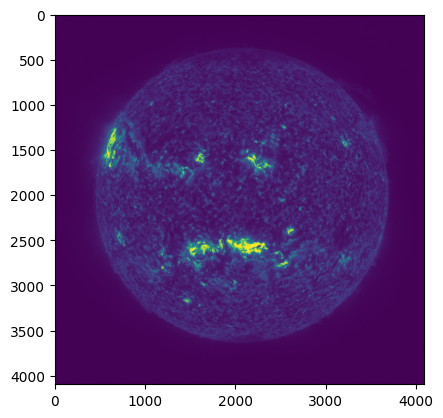

In [136]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot()
ax.imshow(hdulist[1].data, vmin=0, vmax=100)
# Quick note to remember that we do not need to use plt.show() to display the plot in a notebook.

The metadata for this file is all stored in the FITS header. A FITS header can be long and difficult to parse. For example, the names of the keys can only be 8 characters long and can often be quite cryptic.

In [137]:
hdulist[1].header

2025-02-13 21:08:38 - astropy - WARNING: VerifyWarning: Verification reported errors:
2025-02-13 21:08:38 - astropy - WARNING: VerifyWarning: Card 'OSCNMEAN' is not FITS standard (invalid value string: 'nan').  Fixed 'OSCNMEAN' card to meet the FITS standard.
 [astropy.io.fits.verify]
2025-02-13 21:08:38 - astropy - WARNING: VerifyWarning: Note: astropy.io.fits uses zero-based indexing.

2025-02-13 21:08:38 - astropy - WARNING: VerifyWarning: Card 'OSCNRMS' is not FITS standard (invalid value string: 'nan').  Fixed 'OSCNRMS' card to meet the FITS standard.


XTENSION= 'IMAGE   '                                                            
BITPIX  =                   16 / data type of original image                    
NAXIS   =                    2 / dimension of original image                    
NAXIS1  =                 4096 / length of original image axis                  
NAXIS2  =                 4096 / length of original image axis                  
PCOUNT  =                    0                                                  
GCOUNT  =                    1                                                  
BLD_VERS= 'V9R41X'                                                              
LVL_NUM = 1.000000                                                              
T_REC   = '2022-03-28T11:00:07Z'                                                
TRECSTEP= 1.000000                                                              
TRECEPOC= '1977.01.01_00:00:00_TAI'                                             
TRECROUN=                   

While we can access the data and header directly, working like that can pose some challenges. For example, what pixel(s) corresponds to the region on the Sun I am interested in? What coordinate system is my image in? 

We need a way to tie the data and the metadata together to form one coherent unit.

### Creating a `Map`

We create a `sunpy.map.Map` object by passing in the FITS file for a single AIA and SECCHI (STEREO) observation.

In [138]:
import sunpy.map

In [139]:
m_aia = sunpy.map.Map(aia_files[6])

In [140]:
m_stereo = sunpy.map.Map(stereo_files[6])

IndexError: list index out of range

We can easily visualize a map after loading it using the quicklook functionality that is enabled by the notebook.

Observatory,SDO
Instrument,AIA 4
Detector,AIA
Measurement,304.0 Angstrom
Wavelength,304.0 Angstrom
Observation Date,2022-03-28 12:12:05
Exposure Time,2.902056 s
Dimension,[4096. 4096.] pix
Coordinate System,helioprojective
Scale,[0.600165 0.600165] arcsec / pix
Reference Pixel,[2067.688232 2005.608276] pix

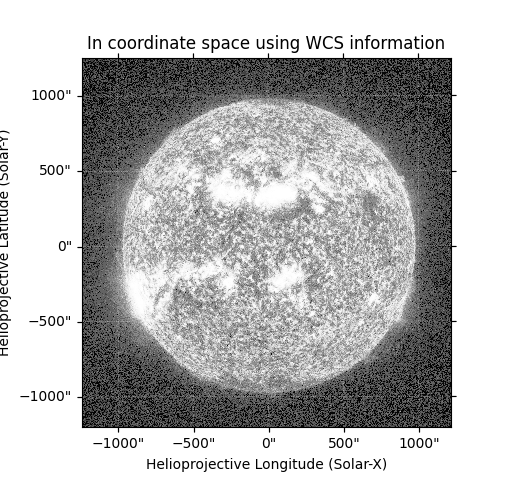
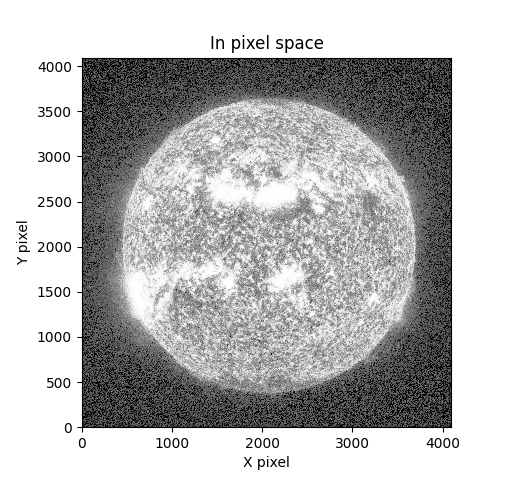
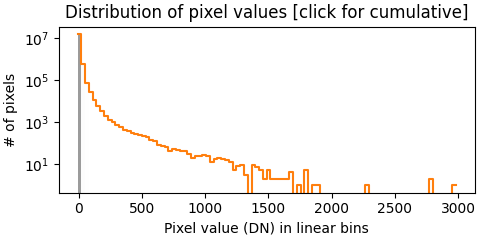
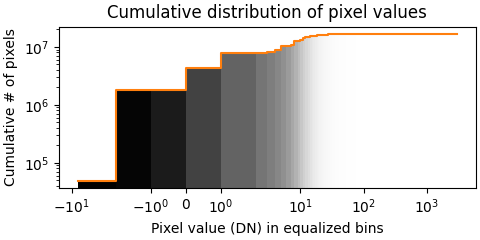

In [142]:
m_aia

Or using the `peek` method

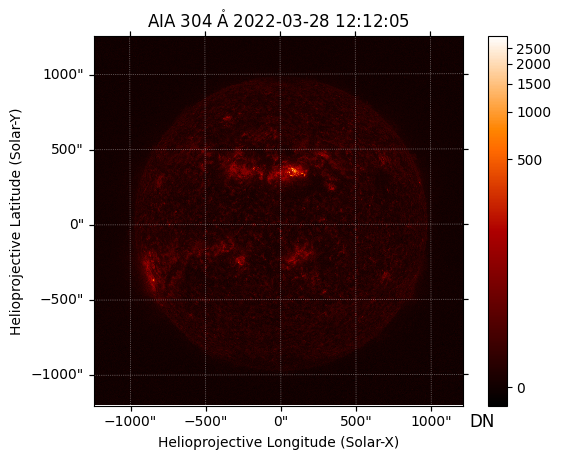

In [144]:
m_aia.peek()

We will talk much more about visualizing maps later on.

### Attributes of a `Map`

`Map` provides a common interface to most 2D imaging solar datasets and provides several useful pieces of metadata.
`Map` is a container for holding your data and metadata (usually from the FITS header) together.

The `.meta` and `.data` attributes provide access to the metadata and underlying array of image data, respectively.

In [145]:
m_aia.data

array([[ 0.,  0.,  1., ..., -2.,  0.,  1.],
       [ 0.,  1.,  1., ..., -1., -1., -1.],
       [ 0.,  1.,  3., ..., -1.,  1., -1.],
       ...,
       [ 0.,  0.,  1., ...,  1.,  1.,  1.],
       [-2.,  1.,  1., ...,  1.,  1., -1.],
       [ 0., -1.,  4., ..., -1.,  1., -1.]],
      shape=(4096, 4096), dtype=float32)

In [146]:
m_aia.meta

MetaDict([('xtension': 'IMAGE')
('bitpix': '16')
('naxis': '2')
('naxis1': '4096')
('naxis2': '4096')
('pcount': '0')
('gcount': '1')
('bld_vers': 'V9R41X')
('lvl_num': '1.0')
('t_rec': '2022-03-28T12:12:07Z')
('trecstep': '1.0')
('trecepoc': '1977.01.01_00:00:00_TAI')
('trecroun': '1')
('origin': 'SDO/JSOC-SDP')
('date': '2022-04-01T06:24:23')
('telescop': 'SDO/AIA')
('instrume': 'AIA_4')
('date-obs': '2022-03-28T12:12:05.12')
('t_obs': '2022-03-28T12:12:06.57Z')
('camera': '4')
('img_type': 'LIGHT')
('exptime': '2.902056')
('expsdev': '0.0002')
('int_time': '3.15625')
('wavelnth': '304')
('waveunit': 'angstrom')
('wave_str': '304_THIN')
('fsn': '253117519')
('fid': '0')
('quallev0': '0')
('quality': '0')
('totvals': '16777216')
('datavals': '16777216')
('missvals': '0')
('percentd': '100.0')
('datamin': '-8')
('datamax': '2980')
('datamedn': '4')
('datamean': '6.68')
('datarms': '14.0')
('dataskew': '25.42')
('datakurt': '1743.59')
('datacent': '9.69')
('datap01': '-1.0')
('datap10':

These are very similar to the outputs we got earlier from parsing the FITS file directly with `astropy`.

This metadata can be terse, non-homogeneous, and sometimes difficult to parse.
`Map` provides several high-level attributes derived from the underlying raw metadata that expose a uniform interface to the metadata for each map.

In [147]:
m_aia.wavelength

<Quantity 304. Angstrom>

In [148]:
m_aia.instrument

'AIA 4'

Each `Map` object also holds the unit system that the image data is in, expressed in terms of an `astropy.unit.Unit` object.

In [149]:
m_aia.unit

Unit("DN")

### Aside - `astropy.coordinates`

#### Coordinate Information

Each `Map` exposes information about which coordinate system the image was taken in, including the location of the spacecraft that recorded that observation.
`sunpy` leverages and extends the powerful `astropy` coordinate framework with solar-specific coordinate frames. 
The `SkyCoord` object is the primary interface for working with coordinates.
`SkyCoord` provides a simple and flexible user interface for celestial coordinate representation, manipulation, and transformation between coordinate frames. 

In [152]:
from astropy.coordinates import SkyCoord

In [153]:
point = SkyCoord(0*u.deg, 0*u.deg, frame='icrs')
point

<SkyCoord (ICRS): (ra, dec) in deg
    (0., 0.)>

Here, the ICRS<a name="icrs-note"></a>[<sup>[1]</sup>](#icrs-note) is just one coordinate frame among many.
`sunpy` adds a number of solar coordinate frames which are automatically registered with `astropy` when you import `sunpy.coordinates`.

In [154]:
point.galactic

<SkyCoord (Galactic): (l, b) in deg
    (96.33728337, -60.18855195)>

This is a specific example but as this is provided without context, let us show how this works within `sunpy`.

<a name="icrs-note"></a>[<sup>[1]</sup>](#icrs-note) A resolution passed in 1997 established the International Celestial Reference System (ICRS), a high precision coordinate
system with its origin at the solar system barycenter and "a space fixed" (kinematically nonrotating) axes. 

#### A solar coordinate frame

An example of a solar-specific coordinate system is the Stonyhurst heliographic (HGS) coordinate system. 
The HGS system is defined with the following Cartesian axes:

* The origin is the center of the Sun
* The Z-axis (+90 degrees latitude) is aligned with the Sun’s north pole.
* The X-axis (0 degrees longitude and 0 degrees latitude) is perpendicular to the Z-axis such that the XZ-plane contains the Sun-Earth line.  That is, Earth is at 0 degrees longitude (but usually not at 0 degrees latitude).
* The Y-axis (+90 degrees longitude and 0 degrees latitude) is perpendicular to both the X-axis and the Z-axis in a right-handed fashion.

Then, the coordinate frame is the realization of this definition at a particular time, which defines the position/orientation of the Sun and the position of the Earth.

Let's create a frame for Stonyhurst heliographic coordinates using sunpy's [`HeliographicStonyhurst` class](https://docs.sunpy.org/en/stable/api/sunpy.coordinates.frames.HeliographicStonyhurst.html):

In [155]:
from sunpy.coordinates import HeliographicStonyhurst

In [156]:
time = '2022-03-28 11:00'
hgs_frame = HeliographicStonyhurst(obstime=time)
hgs_frame

<HeliographicStonyhurst Frame (obstime=2022-03-28T11:00:00.000, rsun=695700.0 km)>

#### Coordinates and different representations

A **coordinate** combines position data with a `SkyCoord`.

In [157]:
# longitude, latitude, and distance from the origin
hgs_coord = SkyCoord(10*u.deg, 20*u.deg, 1*u.AU, frame=hgs_frame)
hgs_coord

<SkyCoord (HeliographicStonyhurst: obstime=2022-03-28T11:00:00.000, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, AU)
    (10., 20., 1.)>

The invidual components of our coordinate can be accessed as properties.

In [158]:
hgs_coord.lon

<Longitude 10. deg>

In [159]:
hgs_coord.lat

<Latitude 20. deg>

In [160]:
hgs_coord.radius

<Distance 1. AU>

This position data can have different **representations**, e.g., spherical components or Cartesian components.

In [161]:
hgs_coord.cartesian

<CartesianRepresentation (x, y, z) in AU
    (0.92541658, 0.16317591, 0.34202014)>

In [162]:
hgs_coord.spherical

<SphericalRepresentation (lon, lat, distance) in (deg, deg, AU)
    (10., 20., 1.)>

#### Observer-based frames

A number of coordinate frames are **observer-based**, which means that the coordinate frame itself is defined by the position of the observer.
For example, helioprojective Cartesian coordinates are aligned such that one axis is aligned with the Sun-observer line.

Let's use the above `HeliographicStonyhurst` coordinate as the observer for a [`Helioprojective` frame](https://docs.sunpy.org/en/stable/api/sunpy.coordinates.frames.Helioprojective.html), here for 2D helioprojective coordinates: $(\theta_x, \theta_y) = (123^{\prime\prime}, 456^{\prime\prime})$.

In [163]:
from sunpy.coordinates import Helioprojective

In [164]:
hpc_frame = Helioprojective(obstime=time, observer=hgs_coord)

In [165]:
SkyCoord(123*u.arcsec, 456*u.arcsec, frame=hpc_frame)

<SkyCoord (Helioprojective: obstime=2022-03-28T11:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-03-28T11:00:00.000, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, AU)
    (10., 20., 1.)>): (Tx, Ty) in arcsec
    (123., 456.)>

Recall that all of the `sunpy.Map`s we created so far are defined in a Helioprojective frame.

### Using Coordinates with `Map`

For each `Map`, we can easily access what *coordinate frame* the observation corresponds to.

In [166]:
m_aia.coordinate_frame

<Helioprojective Frame (obstime=2022-03-28T12:12:06.570, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-03-28T12:12:06.570, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01267568, -6.72325135, 1.49317526e+11)>)>

Similarly, we can look at the location of the observer (as defined by the position of the satellite at the time of the observation).

In [167]:
m_aia.observer_coordinate

<SkyCoord (HeliographicStonyhurst: obstime=2022-03-28T12:12:06.570, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01267568, -6.72325135, 1.49317526e+11)>

We can plot these observer coordinates to show the relative position, in heliographic longitude, of each spacecraft, similar to the SolarMACH plot we showed in our previous notebook.

(**NOTE:** *It is not particularly important to understand the intricacies of the plotting code below. This is merely to show we can use the coordination information in each map to visualize the relative positions of the three spacecraft we are concerned with here.*)

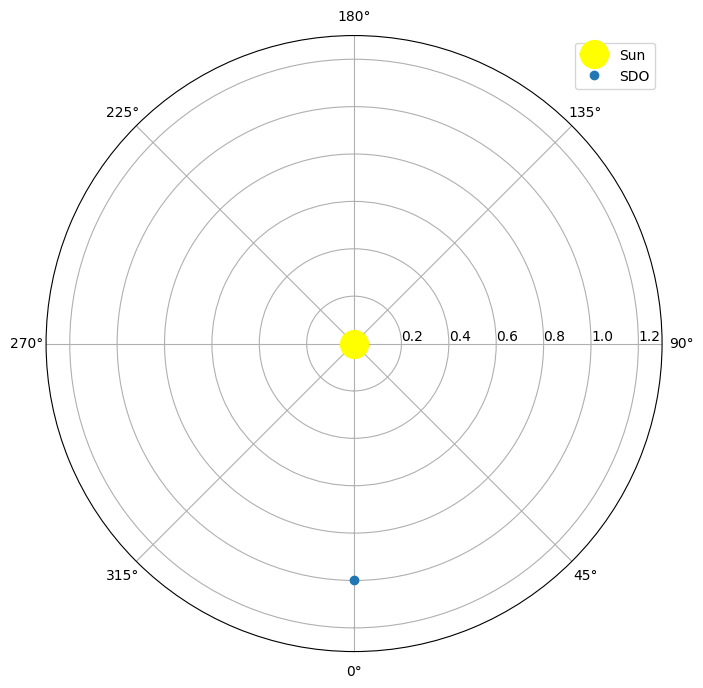

In [ ]:
# Leave this code here
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection='polar')

# Plot the Sun
ax.plot(0, 0, marker='o', markersize=20, label='Sun', color='yellow')

# Plot the satellite locations
for m in [m_aia, m_stereo]:
    sat = m.observatory
    coord = m.observer_coordinate
    ax.plot(coord.lon.to('rad'), coord.radius.to(u.AU), 'o', label=sat)

ax.set_theta_zero_location("S")
ax.set_rlabel_position(90)
ax.set_rlim(0, 1.3)
ax.legend()

### The World Coordinate System

The World Coordinate System or WCS is a framework for transforming between pixel and world coordinates.

In [171]:
m_aia.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'HPLN-TAN' 'HPLT-TAN' 
CRVAL : 0.0 0.0 
CRPIX : 2068.688232 2006.608276 
PC1_1 PC1_2  : 0.99999735818323 0.0022986140539945 
PC2_1 PC2_2  : -0.0022986140539945 0.99999735818323 
CDELT : 0.0001667125 0.0001667125 
NAXIS : 4096  4096

There is a lot of complexity in how the WCS is defined, but for our purposes here, it is just a mechanism for transforming between the *pixel* coordinate system of our image and the *world* coordinate system defined by the coordinate frame in which our image is defined.

We can use the associated `pixel_to_world` and `world_to_pixel` functions to transform between the world and pixel coordinates of our images.

In [172]:
m_aia.wcs.pixel_to_world(0*u.pix, 0*u.pix)

<SkyCoord (Helioprojective: obstime=2022-03-28T12:12:06.570, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-03-28T12:12:06.570, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01267568, -6.72325135, 1.49317526e+11)>): (Tx, Ty) in arcsec
    (-1243.70258921, -1200.80484133)>

In [173]:
m_aia.bottom_left_coord

<SkyCoord (Helioprojective: obstime=2022-03-28T12:12:06.570, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-03-28T12:12:06.570, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01267568, -6.72325135, 1.49317526e+11)>): (Tx, Ty) in arcsec
    (-1243.70258921, -1200.80484133)>

The `bottom_left_coord` is the *center* of the pixel in the bottom left corner of our image.

In [174]:
m_aia.wcs.world_to_pixel(m_aia.bottom_left_coord)

(array(-1.13686838e-10), array(5.52518031e-11))

Similarly, we can confirm that the `center` coordinate falls on the center of the map.

In [175]:
m_aia.center

<SkyCoord (Helioprojective: obstime=2022-03-28T12:12:06.570, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-03-28T12:12:06.570, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.01267568, -6.72325135, 1.49317526e+11)>): (Tx, Ty) in arcsec
    (-12.0584466, 25.16973058)>

In [176]:
m_aia.wcs.world_to_pixel(m_aia.center)

(array(2047.5), array(2047.5))

In [177]:
m_aia.dimensions

PixelPair(x=<Quantity 4096. pix>, y=<Quantity 4096. pix>)

Note that the center of our AIA image does not align with the center of the Sun!

In [178]:
m_aia.wcs.world_to_pixel(SkyCoord(Tx=0*u.arcsec, Ty=0*u.arcsec, frame=m_aia.coordinate_frame))

(array(2067.688232), array(2005.608276))

<div class="alert alert-block alert-warning">
    <emph><u>EXERCISE:</u>
    <br>
    How would you find the position of the center of the STEREO map in the pixel coordinates of the AIA map?
    </emph>
</div>

In [180]:
# INSTRUCTOR BLOCK
m_aia.wcs.world_to_pixel(m_stereo.center)

NameError: name 'm_stereo' is not defined

### Visualization

`Map` provides some additional "helpers" for plotting the associated image data with the correct projection based on the WCS.

At a minimum, this can be accomplished through the `.plot()` method.
It is important to note that this method supports many of the same arguments as `imshow` does.

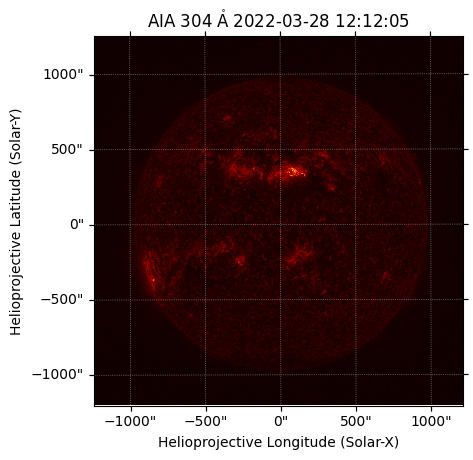

In [181]:
m_aia.plot()

This "automagically" creates a figure and an axis (with a projection based on the WCS of the map) and plots our map on that axis, with a colormap and normalization tailored for the specific map source.
All of this visualization is built on top of `matplotlib` and the `WCSAxes` capabilities provided by `astropy`.
However, as you can see, the resulting default scaling is not particularly useful.

Because all of this plotting capability is built on top of `matplotlib`, we can easily customize the various components of our plot.

<CoordinatesMap with 2 world coordinates:

  index aliases    type   unit    wrap   format_unit visible
  ----- ------- --------- ---- --------- ----------- -------
      0     lon longitude  deg 180.0 deg         deg     yes
      1     lat  latitude  deg      None         deg     yes

>

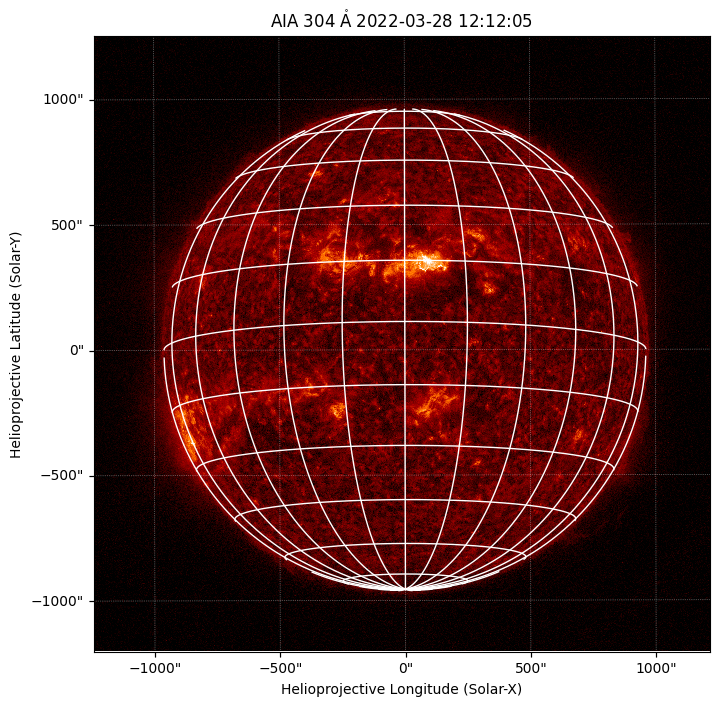

In [182]:
plt.figure(figsize=(8, 8))
m_aia.plot(vmin=0, vmax=500)
m_aia.draw_grid(lw=1, alpha=1)

While it is nice to have `matplotlib` create everything for us, it is easier to customize the plotting process if we create the figure and axis ourselves.
This can be important when we have multiple figures within a notebook.

So we will now  create a figure and axis and add the projection for the map.
We can also easily adjust the limits on our colorbar using the `clip_interval` key.

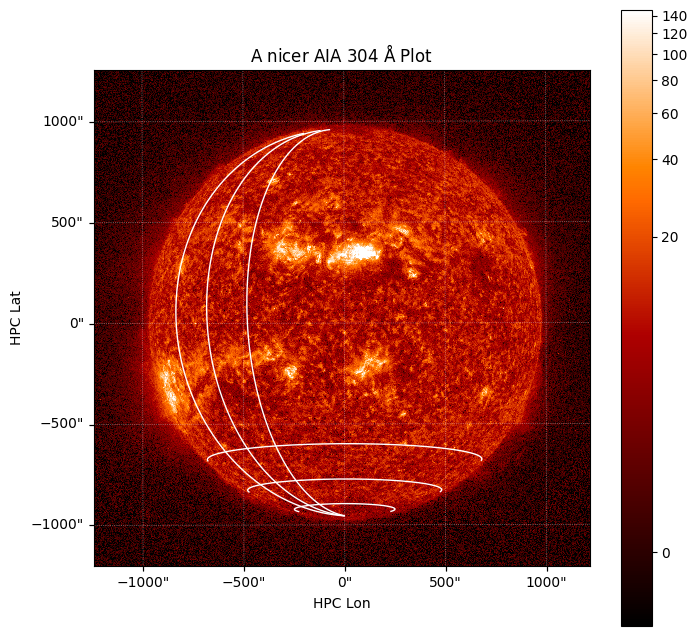

In [183]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=m_aia)
im = m_aia.plot(axes=ax, clip_interval=(5,99.9)*u.percent)
grid = m_aia.draw_grid(axes=ax, lw=1, alpha=1)
ax.set_title(r'A nicer AIA 304 $\mathrm{\AA}$ Plot')
ax.coords[0].set_axislabel('HPC Lon')
ax.coords[1].set_axislabel('HPC Lat')
# This is just an example, it isn't the most useful
grid['lon'].set_ticks([-30, -45, -60] * u.deg)
grid['lat'].set_ticks([-45, -60, -75] * u.deg)
fig.colorbar(im)

Or specify a new normalization altogether

In [184]:
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.visualization import LogStretch

In [185]:
norm = ImageNormalize(vmin=0, vmax=50, stretch=LogStretch())

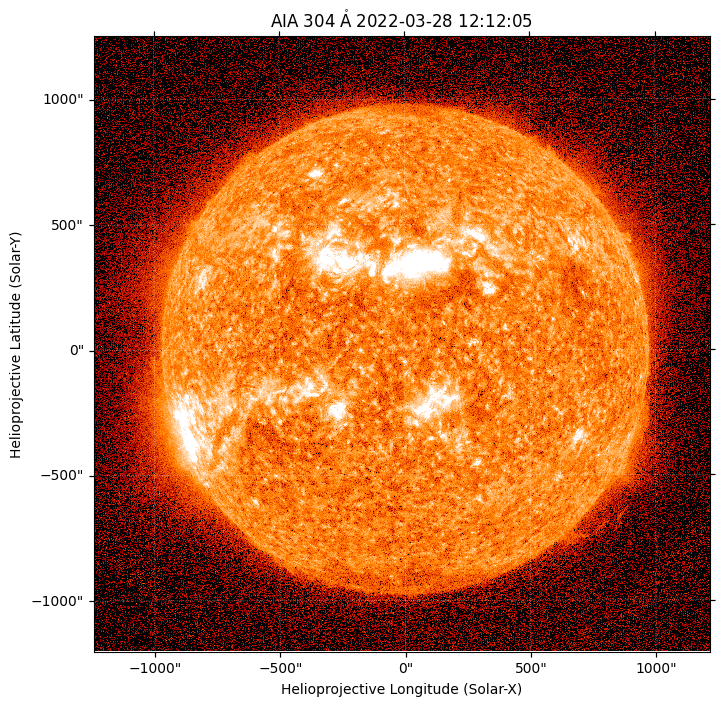

In [186]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=m_aia)
m_aia.plot(axes=ax,norm=norm)

<div class="alert alert-block alert-warning">
    <emph><u>EXERCISE:</u> <br>How would I change the colormap for the above plot?</emph>
</div>

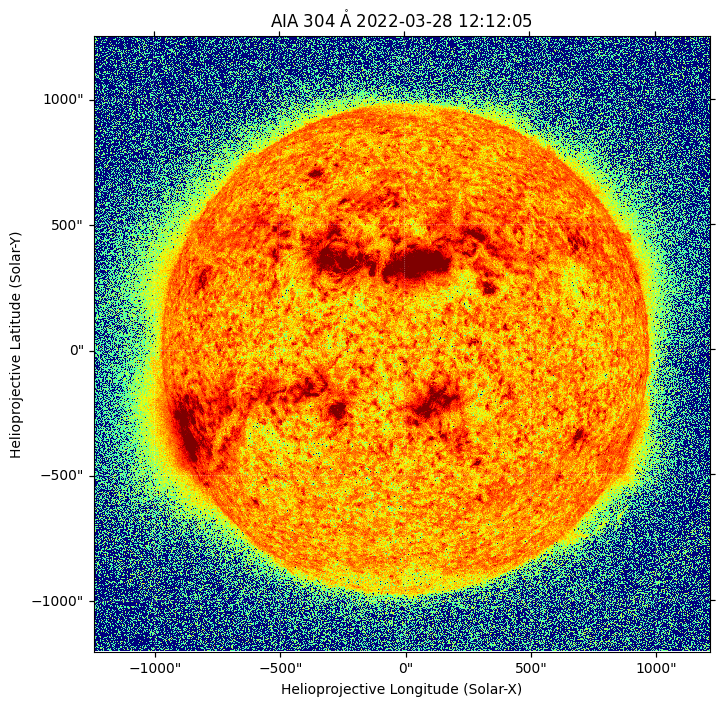

In [187]:
# INSTRUCTOR BLOCK
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=m_aia)
m_aia.plot(axes=ax,norm=norm, cmap='jet')

Using `matplotlib` combined with `WCSAxes`, we can build more complex, publication-quality visualizations.

(**NOTE:** It is not necessary to fully understand every intricacy of the plotting code below during the course of the tutorial. This is merely to show how `Map.plot` can be be used to make more complex plots.)

In [188]:
# Leave this code here
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import numpy as np

fig = plt.figure(figsize=(20,10))

for i, m in enumerate([m_aia, m_stereo]):
    # Create the axis with the appropriate projection
    ax = fig.add_subplot(1,3,i+1,projection=m)

    # Add the plot to the axis
    im = m.plot(axes=ax, annotate=False, clip_interval=(1,99.9)*u.percent)

    # Make the HPC grid lines visible
    ax.coords.grid(alpha=1, ls='-')

    # Adjust the labels and ticks
    if i > 0:
        ax.coords[1].set_auto_axislabel(False)
    else:
        ax.coords[1].set_axislabel('Solar-Y')
    ax.coords[0].set_axislabel('Solar-X')
    ax.coords[1].set_ticklabel(rotation=90,)

    # Put a label on each plot
    ax.text(m.data.shape[1]//2, m.data.shape[0]*.97, m.observatory,
            color='w',
            horizontalalignment='center',
            verticalalignment='top',
            fontsize=14)

    # Add a colorbar to the top of each plot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('top', size='4%', pad=0.2, axes_class=plt.Axes)
    fig.colorbar(im, cax=cax, orientation='horizontal')

    cax.xaxis.set_ticks_position("top")
    cax.xaxis.set_tick_params(direction='in')

plt.subplots_adjust(wspace=0.1)

NameError: name 'm_stereo' is not defined

<Figure size 2000x1000 with 0 Axes>

#### Overplotting Coordinates on a `Map`

Let's use our newfound knowledge of coordinates to plot the positions of the detected flares around the time we know that the CME initiated.
To find the metadata for any flares that were detected at this time, we'll again use `Fido` to query the Heliophysics Event Knowledgebase (HEK).

> The Heliophysics Events Knowledgebase (HEK) system is being developed to help solar and heliospheric researchers locate features and events of interest to their science topics.

This can be done by using the HEK client specific attributes `a.hek.attrs`.
We'll choose only flare events who have a GOES class above C2.5

In [189]:
hek_result = Fido.search(
    a.Time(cme_start, cme_end),
    a.hek.EventType('FL'),
    a.hek.FL.GOESCls > 'C2.5'
)

The HEK keeps track of a lot of information for each event in the database.

In [190]:
hek_result['hek']

gs_thumburl,comment_count,hpc_bbox,frm_humanflag,hgc_coord,event_coordsys,obs_levelnum,hpc_coord,event_npixels,gs_imageurl,ar_polarity,frm_paramset,hrc_coord,event_starttime,ar_mtwilsoncls,event_type,intensmin,fl_fluence,obs_meanwavel,frm_url,skel_chaincode,bound_chaincode,noposition,fl_fluenceunit,active,intensmax,frm_versionnumber,fl_peaktempunit,fl_halphaclass,area_uncert,obs_dataprepurl,hpc_geom,hgc_bbox,intensmedian,chaincodetype,obs_channelid,event_clippedspatial,ar_noaaclass,SOL_standard,event_avg_rating,eventtype,intensunit,hpc_boundcc,event_mapurl,frm_contact,ar_penumbracls,intensmean,bound_ccstartc1,frm_name,area_atdiskcenter,frm_identifier,obs_observatory,event_description,boundbox_c2ur,obs_firstprocessingdate,boundbox_c2ll,frm_institute,hrc_bbox,refs_orig,ar_mcintoshcls,event_maskurl,bound_ccstartc2,gs_movieurl,event_score,skel_startc2,skel_startc1,fl_efoldtime,event_expires,fl_efoldtimeunit,hrc_boundcc,event_probability,intensvar,frm_daterun,event_coordunit,hpc_y,hpc_x,search_instrument,ar_numspots,kb_archivdate,kb_archivist,intenstotal,sum_overlap_scores,hgs_boundcc,intensskew,obs_includesnrt,rasterscan,obs_wavelunit,kb_archivid,search_frm_name,boundbox_c1ur,ar_noaanum,area_atdiskcenteruncert,boundbox_c1ll,event_importance_num_ratings,ar_compactnesscls,skel_curvature,event_testflag,event_c2error,hrc_r,skel_nsteps,hgs_y,obs_title,fl_peakemunit,hgs_x,hcr_checked,frm_specificid,event_title,obs_instrument,event_c1error,revision,hpc_radius,event_endtime,event_importance,event_coord2,event_coord3,event_coord1,search_observatory,area_raw,concept,solar_object_locator,event_pixelunit,hgc_boundcc,fl_peakflux,hgc_x,hrc_a,event_peaktime,hgc_y,gs_galleryid,fl_goescls,hgs_coord,ar_zurichcls,bound_ccnsteps,intenskurt,event_clippedtemporal,fl_peakfluxunit,fl_peakem,rasterscantype,search_channelid,fl_peaktemp,hgs_bbox,area_unit,obs_lastprocessingdate,refs
str131,str1,str110,str5,str19,str12,object,str27,object,str130,object,str57,str41,Time,str1,str2,object,object,float64,str82,str1,str1,str5,str1,str4,object,object,str1,str1,object,str1,str186,str90,object,str1,str3,str1,str1,str30,object,str1,str1,str1,str1,str23,str1,object,object,str17,object,str9,str4,str1,float64,str1,float64,str61,str110,str1,str1,str1,object,str99,str20,object,object,object,str1,str1,str1,object,object,str19,str7,float64,float64,str4,object,str19,str19,object,str1,str1,object,str1,str1,str2,str66,str17,float64,int64,object,float64,str1,str1,object,str5,int64,float64,object,int64,str1,str1,int64,str4,str1,str1,str4,int64,str1,str19,Time,object,int64,object,int64,str4,object,str5,str30,str1,str1,object,float64,float64,Time,int64,str1,str4,str11,str1,object,object,str1,str1,object,str1,str19,object,str66,str1,str1,object
,0,"POLYGON((-1.677645 -954.6888,1.677645 -954.6888,1.675979 953.64696,-1.675979 953.64696,-1.677645 -954.6888))",false,POINT(83.793532 0),UTC-HGS-TOPO,None,POINT(0 113.204178),None,,None,"SSWIDL get_gev, ..., ngdc=0",POINT(0.117822932386111 0),2022-03-28 10:58:00.000,,FL,None,None,5e-08,http://www.swpc.noaa.gov/,,,true,,true,None,None,,,None,,,"POLYGON((-6.106468 -89.9,173.693532 -89.9,173.693532 89.9,-6.106468 89.9,-6.106468 -89.9))",None,,XRA,,,SOL2022-03-28T10:58:00L083C090,None,9,,,,SWPC.Webmaster@noaa.gov,,None,None,SWPC,None,SWPC,GOES,,89.9000015258789,,-89.9000015258789,"U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center","POLYGON((0.993642 179.899316,0.993642 180.100684,0.992557 359.899306,0.992557 0.100694,0.993642 179.899316))",,,,None,,0.679999999999999938,None,None,None,,,,None,None,2022-03-28T00:00:00,degrees,113.204178,0.0,GOES,None,2022-05-25T16:23:44,autosubmission_swpc,None,0,,None,,,cm,ivo://helio-informatics.org/FL_SWPC_20220525_162342_20220328105800,SWPC,89.9000015258789,0,None,-89.9000015258789,,,None,false,90,0.117822932386111,None,0,,,0,true,,,GOES,90,1,113.204177999999999,2022-03-28 11:45:00.000,None,0,None,0,GOES,None,Flare,SOL2022-03-28T10:58:00L083C090,,,None,83.793532,0.0,2022-03-28 11:29:00.000,0,,M4.

Let's filter this down to the start, end, and peak times of the flare, the GOES classification, and the coordinates of the flare on the disk.

In [191]:
flare_table = hek_result['hek'][
    'event_starttime',
    'event_peaktime',
    'event_endtime',
    'fl_goescls',
    'hpc_x',
    'hpc_y',
]

In [192]:
flare_table

event_starttime,event_peaktime,event_endtime,fl_goescls,hpc_x,hpc_y
Time,Time,Time,str4,float64,float64
2022-03-28 10:58:00.000,2022-03-28 11:29:00.000,2022-03-28 11:45:00.000,M4.0,0.0,113.204178
2022-03-28 10:58:00.000,2022-03-28 11:29:00.000,2022-03-28 11:45:00.000,M4.0,65.315424,341.386302
2022-03-28 13:44:00.000,2022-03-28 14:54:00.000,2022-03-28 15:50:00.000,C2.7,64.701222,372.559014


To further understand whether these flares in the HEK database correspond to the observed CME, we can plot the positions of the flares that occurred near the start of our observing interval on our AIA image.
We'll do this by first constructing a coordinate for each flare using the HPC positions returned by the HEK.
Though not explicitly stated here, these coordinates are computed assuming an Earth-based observer at the start time of the event.
We can get a `SkyCoord` denoting the position of Earth using the `sunpy.coordinates.get_earth` function.

In [193]:
from sunpy.coordinates import get_earth

In [194]:
# Leave this code here
flare_coords = []
for fl in flare_table:
    earth = get_earth(fl['event_starttime'])
    hpc_frame = Helioprojective(obstime=fl['event_starttime'], observer=earth)
    hpc_coord = SkyCoord(Tx=fl['hpc_x']*u.arcsec, Ty=fl['hpc_y']*u.arcsec, frame=hpc_frame)
    flare_coords.append(hpc_coord)

Finally, let's overplot these coordinates on our AIA and EUVI images.
The `plot_coord` command takes in a `SkyCoord` object and automatically transforms the coordinate to the coordinate system defined by the WCS on that axis.

In [195]:
# Leave this code here
fig = plt.figure(figsize=(15,7.5))
for i,m in enumerate([m_aia, m_stereo]):
    ax = fig.add_subplot(1,2,i+1, projection=m)
    m.plot(axes=ax,clip_interval=(25,99.5)*u.percent)
    for fl in flare_coords:
        ax.plot_coord(fl, marker='X', color='C0', markersize=15)

NameError: name 'm_stereo' is not defined

<Figure size 1500x750 with 0 Axes>

We find that one of the flares queried from the HEK coincides with our observed CME while the other is offset to the south.

#### Animations with `MapSequence`

In addition, the `MapSequence` container provides a data container for holding multiple maps, e.g. when you have a sequence of maps taken at successive times.
We can create `MapSequence` objects by passing in our list of files and the `sequence=True` keyword argument.

In [196]:
stereo_seq = sunpy.map.Map(stereo_files, sequence=True)

RuntimeError: No maps loaded

In [197]:
stereo_seq

NameError: name 'stereo_seq' is not defined

The `MapSequence` can be indexed to return the individual `Map` objects at each time step.

One of the most useful features of a `MapSequence` is the ability to create coordinate-aware visualizations of our stack of `Map` objects.
To do this, we'll first create a a colormap normalization appropriate to the range of the data for every map in our stack.

In [198]:
from astropy.visualization import AsymmetricPercentileInterval

vmin, vmax = AsymmetricPercentileInterval(1, 99.5).get_limits(stereo_seq.as_array())
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=LogStretch())

NameError: name 'stereo_seq' is not defined

The `plot` method on our `MapSequence` object now returns an animation rather than a simple static plot.

In [199]:
plt.figure(figsize=(10,10))
stereo_ani = stereo_seq.plot(norm=norm)

NameError: name 'stereo_seq' is not defined

<Figure size 1000x1000 with 0 Axes>

In [200]:
from IPython.display import HTML

HTML(stereo_ani.to_jshtml())

NameError: name 'stereo_ani' is not defined

### Basic Image Manipulation

There are several methods on the `Map` object that provide capabilities for doing basic image manipulation in combination with the coordinate information attached to each `Map`.

#### Rotate

The `.rotate` method applies a rotation in the image plane, i.e. about an axis out of the page. 
In the case where we do not specify an angle (or rotation matrix), the image will be rotated such that the world and pixel axes are aligned.
In the case of an image in helioprojective coordinate system, this means that solar north will be aligned with the y-like pixel axis of the image.

In [201]:
m_stereo_rot = m_stereo.rotate(missing=m_stereo.min())

NameError: name 'm_stereo' is not defined

By default, any missing values will be filled with "NaN". Here, we specify `missing` as the minimum intensity value of the map.

In [202]:
fig = plt.figure(figsize=(11,5), layout='constrained')

ax = fig.add_subplot(121,projection=m_stereo)
m_stereo.plot(axes=ax, vmin=800, vmax=5000)
ax.coords.grid(alpha=1, ls='-')

ax = fig.add_subplot(122,projection=m_stereo_rot)
m_stereo_rot.plot(axes=ax, vmin=800, vmax=5000)
ax.coords.grid(alpha=1, ls='-')

NameError: name 'm_stereo' is not defined

<Figure size 1100x500 with 0 Axes>

This rotation is also reflected in the updated metadata of the rotated image.

In [203]:
m_stereo.rotation_matrix

NameError: name 'm_stereo' is not defined

In [204]:
m_stereo_rot.rotation_matrix

NameError: name 'm_stereo_rot' is not defined

Additionally, one can also specify some arbitrary angle to rotate the image by.
Note that this angle is relative to the current orientation of the image.

<div class="alert alert-block alert-warning">
    <emph><u>EXERCISE:</u>
    <br>
    How would you rotate the image such that there is exactly a 45 degree orientation between the world and pixel axes?
    </emph>
</div>

In [205]:
# INSTRUCTOR BLOCK
m_stereo_45 = m_stereo.rotate(missing=m_stereo.min()).rotate(angle=45*u.degree, missing=m_stereo.min())

fig = plt.figure(figsize=(5,5))

ax = fig.add_subplot(projection=m_stereo_45)
m_stereo_45.plot(axes=ax, vmin=800, vmax=5000)
ax.coords.grid(alpha=1, ls='-')

NameError: name 'm_stereo' is not defined

#### Cropping Images

We commonly want to pare down our full field-of-view to a particular region of interest.
With a map, we can do this using the `submap` method.
We can specify the region of our submap using world coordinates as specified by a `SkyCoord`.
We will specify these coordinates in Heliographic Stonyhurst (HGS) coordinates.
From the animation of the STEREO data above, we can identify approximately where the CME was launched from and crop our image around that region.

In [206]:
bottom_left = SkyCoord(lon=-20*u.deg, lat=-5*u.deg, radius=1*sunpy.sun.constants.radius,
                       frame='heliographic_stonyhurst', obstime=m_aia.date)
top_right = SkyCoord(lon=30*u.deg, lat=35*u.deg, radius=1*sunpy.sun.constants.radius,
                     frame='heliographic_stonyhurst', obstime=m_aia.date)

In [207]:
m_stereo_cropped = m_stereo.submap(bottom_left, top_right=top_right)

NameError: name 'm_stereo' is not defined

In [208]:
m_stereo_cropped

NameError: name 'm_stereo_cropped' is not defined

The coordinates for our cutout can also be specified in pixel coordinates.

<div class="alert alert-block alert-warning">
    <emph><u>EXERCISE:</u> <br>The coordinates for our cutout can also be specified in pixel coordinates. Find the corners of our cutout in pixel coordinates and then create the same submap using those pixel coordinates.
</emph>
</div>

In [209]:
# INSTRUCTOR BLOCK
bl_pix = m_stereo.wcs.world_to_pixel(m_stereo_cropped.bottom_left_coord)
tr_pix = m_stereo.wcs.world_to_pixel(m_stereo_cropped.top_right_coord)
m_stereo.submap(bl_pix*u.pixel, top_right=tr_pix*u.pixel)

NameError: name 'm_stereo' is not defined

## Part 3 - The `Timeseries` Data Structure

In addition to `Map` for 2D image data, `sunpy` also provides a container for tabular time series data through the `TimeSeries` class.
We can create a `TimeSeries` object in a very similar manner to how we create a `Map` object.

Let's look at the corresponding GOES XRS data that we downloaded above.

In [210]:
goes_files = sorted((DATA_DIR / 'data/XRS/').glob('*.nc'))

In [211]:
import sunpy.timeseries

In [212]:
ts = sunpy.timeseries.TimeSeries(goes_files)

/Users/nabil/micromamba/envs/sunpy-dev/lib/python3.13/site-packages/astropy/stats/histogram.py:233: RuntimeWarning: invalid value encountered in scalar divide
  Nbins = np.ceil((data.max() - data.min()) / dx)


<sunpy.timeseries.sources.goes.XRSTimeSeries object at 0x16c041d30>
SunPy TimeSeries
----------------
Observatory:			GOES-17
Instrument:			<a href=https://www.swpc.noaa.gov/products/goes-x-ray-flux target="_blank">Unknown</a>
Channel(s):			xrsa<br>xrsb<br>xrsa_quality<br>xrsb_quality<br>xrsa_primary_chan<br>xrsb_primary_chan
Start Date:			2022-03-28 00:00:00
End Date:			2022-03-28 23:59:59
Center Date:			2022-03-28 11:59:59
Resolution:			1.0 s
Samples per Channel:		86400
Data Range(s):		xrsa                8.78E-06<br>xrsb                4.10E-05<br>xrsa_quality        6.70E+01<br>xrsb_quality        6.70E+01<br>xrsa_primary_chan   0.00E+00<br>xrsb_primary_chan   0.00E+00
Units:			W / m2<br>dimensionless
                                    xrsa      xrsb  xrsa_quality  \
2022-03-27 23:59:59.511091  4.832270e-08  0.000001             0   
2022-03-28 00:00:00.511087  5.866761e-08  0.000001             0   
2022-03-28 00:00:01.511085  5.398389e-08  0.000001             0   
2022-03-28 00:00:02.511080  4.365171e-08  0.000001             0   
2022-03-28 00:00:03.511076  5.115329e-08  0.000001             0   
...                                  ...       ...           ...   
2022-03-28 23:59:55.114166  1.657209e-07  0.000003             0   
2022-03-28 23:59:56.114156  1.610501e-07  0.000003             0   
2022-03-28 23:59:57.114153  1.779445e-07  0.000003             0   
2022-03-28 23:59:58.114152  1.694909e-07  0.000003             0   
2022-03-28 23:59:59.114147  1.676123e-07  0.000003             0   

                            xrsb_quality  xrsa_primary_chan  xrsb_primary_chan  
2022-03-27 23:59:59.511091             0                  1                  1  
2022-03-28 00:00:00.511087             0                  1                  1  
2022-03-28 00:00:01.511085             0                  1                  1  
2022-03-28 00:00:02.511080             0                  1                  1  
2022-03-28 00:00:03.511076             0                  1                  1  
...                                  ...                ...                ...  
2022-03-28 23:59:55.114166             0                  1                  1  
2022-03-28 23:59:56.114156             0                  1                  1  
2022-03-28 23:59:57.114153             0                  1                  1  
2022-03-28 23:59:58.114152             0                  1                  1  
2022-03-28 23:59:59.114147             0                  1                  1  

[86400 rows x 6 columns]
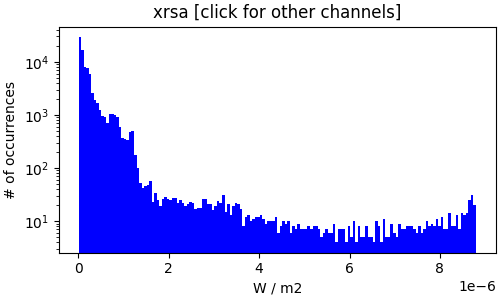
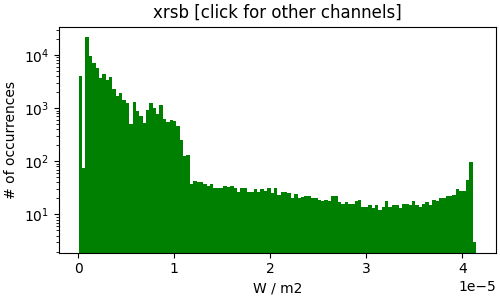
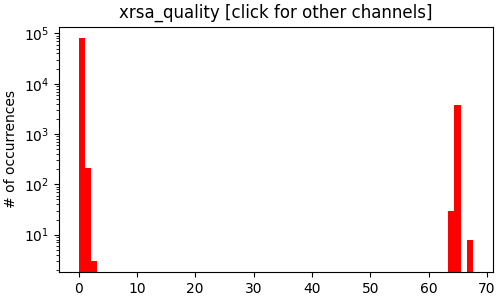
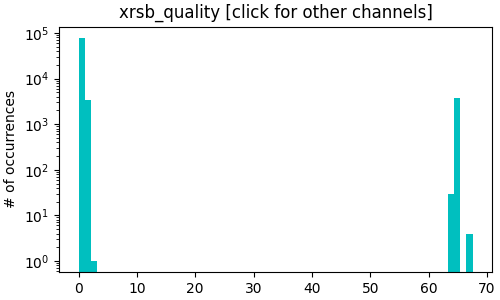
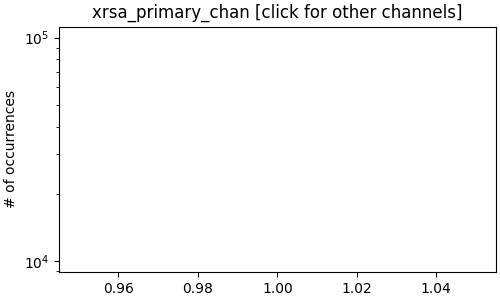
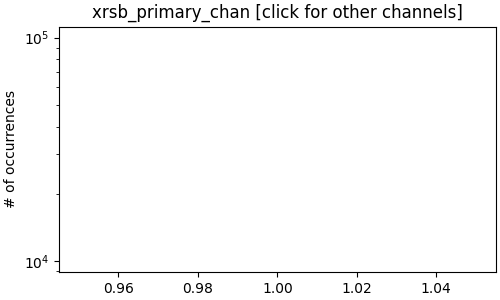
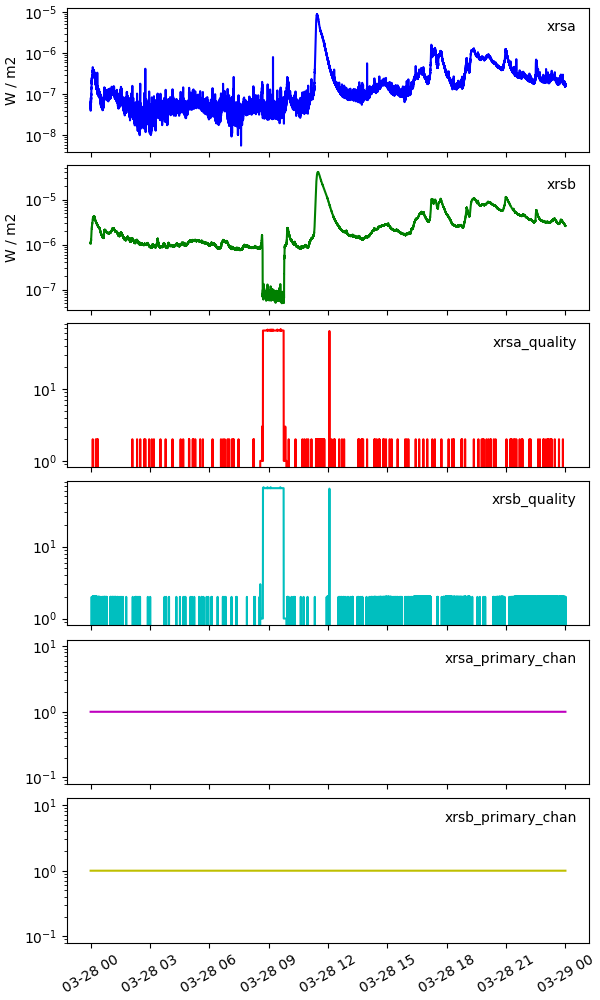
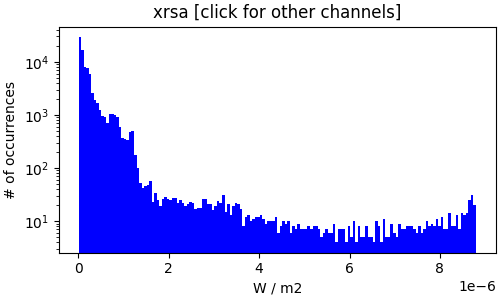

In [213]:
ts

As with `Map`, `TimeSeries` acts as a container for the data + metadata. We can access each component individually.

In [214]:
ts.meta

|-------------------------------------------------------------------------------------------------|
|TimeRange                  | Columns         | Meta                                              |
|-------------------------------------------------------------------------------------------------|
|2022-03-27T23:59:59.511091 | xrsa            | conventions: ACDD-1.3, Spase v2.2.6               |
|            to             | xrsb            | title: L2 XRS 1-s fluxes                          |
|2022-03-28T23:59:59.114147 | xrsa_quality    | summary: The X-Ray 1s flux product consists of hig|
|                           | xrsb_quality    | keywords: NumericalData.MeasurementType.Irradiance|
|                           | xrsa_primary_ch | keywords_vocabulary: SPASE: Space Physics Archive |
|                           | xrsb_primary_ch | naming_authority: gov.nesdis.noaa                 |
|                           |                 | history: See algorithm information.               |


The `TimeSeries` object can also be converted to other formats like an `astropy` `Table` object

In [215]:
ts.to_table()

date,xrsa,xrsb,xrsa_quality,xrsb_quality,xrsa_primary_chan,xrsb_primary_chan
,W / m2,W / m2,,,,
datetime64[ns],float32,float32,uint16,uint16,uint8,uint8
2022-03-27T23:59:59.511091000,4.83227e-08,1.0639529e-06,0,0,1,1
2022-03-28T00:00:00.511087000,5.8667606e-08,1.0764581e-06,0,0,1,1
2022-03-28T00:00:01.511085000,5.3983893e-08,1.0646678e-06,0,0,1,1
2022-03-28T00:00:02.511080000,4.365171e-08,1.066056e-06,0,0,1,1
2022-03-28T00:00:03.511076000,5.1153293e-08,1.0702107e-06,0,0,1,1
2022-03-28T00:00:04.511071000,6.149821e-08,1.0736918e-06,0,0,1,1
2022-03-28T00:00:05.511067000,4.553029e-08,1.0716093e-06,0,0,1,1
2022-03-28T00:00:06.511059000,5.397116e-08,1.0577158e-06,0,0,1,1


or a `pandas` `DataFrame`

In [216]:
ts.to_dataframe()

,xrsa,xrsb,xrsa_quality,xrsb_quality,xrsa_primary_chan,xrsb_primary_chan
2022-03-27 23:59:59.511091,4.832270e-08,0.000001,0,0,1,1
2022-03-28 00:00:00.511087,5.866761e-08,0.000001,0,0,1,1
2022-03-28 00:00:01.511085,5.398389e-08,0.000001,0,0,1,1
2022-03-28 00:00:02.511080,4.365171e-08,0.000001,0,0,1,1
2022-03-28 00:00:03.511076,5.115329e-08,0.000001,0,0,1,1
...,...,...,...,...,...,...
2022-03-28 23:59:55.114166,1.657209e-07,0.000003,0,0,1,1
2022-03-28 23:59:56.114156,1.610501e-07,0.000003,0,0,1,1
2022-03-28 23:59:57.114153,1.779445e-07,0.000003,0,0,1,1
2022-03-28 23:59:58.114152,1.694909e-07,0.000003,0,0,1,1


There are also a number of attributes on each `TimeSeries` derived from the data/metadata.

In [217]:
ts.columns

['xrsa',
 'xrsb',
 'xrsa_quality',
 'xrsb_quality',
 'xrsa_primary_chan',
 'xrsb_primary_chan']

In [218]:
ts.observatory

'GOES-17'

In [219]:
ts.units

OrderedDict([('xrsa', Unit("W / m2")),
             ('xrsb', Unit("W / m2")),
             ('xrsa_quality', Unit(dimensionless)),
             ('xrsb_quality', Unit(dimensionless)),
             ('xrsa_primary_chan', Unit(dimensionless)),
             ('xrsb_primary_chan', Unit(dimensionless))])

### Slicing and Visualizing `TimeSeries`

Note that this intensity `TimeSeries` spans 24 h of observation time and recall that we are only interested in the ~3 h interval in which the CME is visible in the 304 channel.

We can truncate our timeseries around the times of interest.
To do this, we can actually use the `date` property on our first and last EUI map from our sequence.

In [220]:
from sunpy.time import TimeRange

In [224]:
ts_cme = ts.truncate(TimeRange(stereo_seq[0].date, b=stereo_seq[-1].date))

NameError: name 'stereo_seq' is not defined

And then do a quicklook on our lightcurve.

In [225]:
ts_cme

NameError: name 'ts_cme' is not defined

As expected, we find that there is a flare occurring right around the time the CME occurs. This should not be surprising as we saw from the AIA data that the CME was Earth-directed such that GOES was well-position to observed the flare.

We can also zoom in a bit on the beginning of the flare.

NameError: name 'ts_cme' is not defined

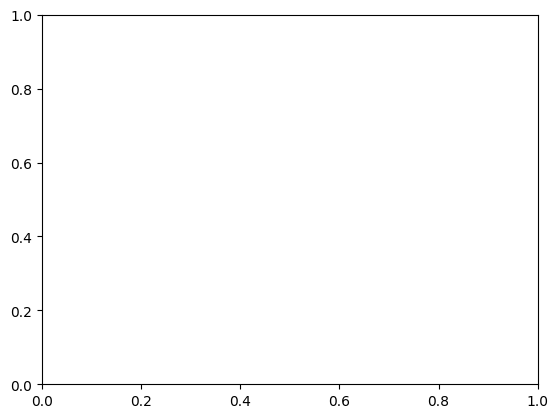

In [223]:
fig = plt.figure()
ax = fig.add_subplot(111)
ts_cme.plot(axes=ax)
ax.set_xlim('2022-03-28 11:00', '2022-03-28 11:30')

As expected, we find that the flare, as detected by GOES, begins just before the eruption is seen by STEREO at 11:20.

### Combining GOES and HEK 

Additionally, let's load back in our GOES XRS timeseries over the entire time interval of interest.
Let's plot the times of the flares on top of our untruncated timeseries.
We'll indicate each flare with a shaded blue region and our original time interval of interest that we used to query our imaging observations with orange.

In [ ]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111)
ts.plot(axes=ax)
ax.axvspan(cme_start, cme_end, alpha=0.25, color='C1')
for fl in flare_table:
    ax.axvspan(fl['event_starttime'].iso, fl['event_endtime'].iso,
               color='C0', alpha=0.25)

## Conclusion

In this notebook, we've learned how to use `sunpy`, including functionality from `astropy`, to search for, download, load and manipulate both 2D image as well as time series data. In particular, we learned how to:

- Create and manipulate unitful quantities with `astropy.units`
- Create and do basic arithmetic with `astropy.time.Time` objects 
- Search for data from many different data providers with `sunpy`
- Load, manipulate, and visualize 2D images data with `sunpy.map.Map`
- Do basic coordinate tranformations with the `astropy.coordinates` framework, include solar coordinate frames
- Create and visualize time series data with `sunpy.timeseries.TimeSeries`

Many more examples of how to use `sunpy` to accomplish these and other similar tasks can be found in the [`sunpy` example gallery](https://docs.sunpy.org/en/stable/generated/gallery/).